# STTP-Net — exp01 Baseline (Best Result)

**This is the exact code that produced:**
- Test Accuracy: **0.9042**
- Balanced Accuracy: **0.8686**

**Architecture:** ResNet-50 + CVAE + SupCon + HybridMix + DualHead + EBS Loss

---
**Always: Restart Kernel → Run All Cells. Never run cells individually.**

## 0. Install (run once)

In [ ]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
# !pip install timm pandas numpy scikit-learn matplotlib seaborn tqdm

In [ ]:
import psutil
print(f'Available RAM: {psutil.virtual_memory().available / 1e9:.1f} GB')

## 1. Imports + Paths + Config

In [1]:

import os, random, warnings, json
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from matplotlib.patches import Patch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.metrics import (classification_report, confusion_matrix,
                              balanced_accuracy_score, roc_auc_score)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# ── Seed ──────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── PATHS  <--- UPDATE THIS ───────────────────────────────────────────────────
BASE_DIR  = r'D:\class imbalance\date-16'   # <-- your path

DATA_DIR  = os.path.join(BASE_DIR, 'data')
RAW_DIR   = os.path.join(DATA_DIR, 'raw')
IMAGE_DIR = os.path.join(RAW_DIR,  'images')
META_PATH = os.path.join(RAW_DIR,  'metadata.csv')
SPLIT_DIR = os.path.join(DATA_DIR, 'splits')
TRAIN_CSV = os.path.join(SPLIT_DIR, 'train.csv')
VAL_CSV   = os.path.join(SPLIT_DIR, 'val.csv')
TEST_CSV  = os.path.join(SPLIT_DIR, 'test.csv')
CKPT_DIR  = os.path.join(BASE_DIR,  'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 16
NUM_WORKERS   = 0
ENCODER_DIM   = 512
LATENT_DIM    = 128
NUM_CLASSES   = 7
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
EPOCHS_PHASE1 = 30
EPOCHS_PHASE2 = 10
TEMPERATURE   = 0.07
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Class metadata ────────────────────────────────────────────────────────────
CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
LABEL2IDX   = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX2LABEL   = {i: c for c, i in LABEL2IDX.items()}
HEAD_THRESH = 1000
TAIL_THRESH = 500
COLORS      = {'head': '#2ecc71', 'median': '#f39c12', 'tail': '#e74c3c'}

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'Device       : {DEVICE}')
print(f'BASE_DIR     : {BASE_DIR}')
print(f'metadata.csv : {os.path.exists(META_PATH)}')
print(f'train.csv    : {os.path.exists(TRAIN_CSV)}')
print(f'images dir   : {os.path.exists(IMAGE_DIR)}')
assert os.path.exists(META_PATH), 'metadata.csv not found — check BASE_DIR'
print('All paths OK.')

Device       : cuda
BASE_DIR     : D:\class imbalance\date-16
metadata.csv : True
train.csv    : True
images dir   : True
All paths OK.


In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # force NVIDIA GPU
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)
print(torch.cuda.get_device_name(0))  # should print RTX 5050

cuda
NVIDIA GeForce RTX 5050 Laptop GPU


In [3]:
# Should show RTX 5050, NOT Radeon
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 5050 Laptop GPU


## 13. Training Curves

## 2. Load Data & EDA

In [4]:
def load_splits():
    if os.path.exists(TRAIN_CSV):
        print('Loading existing split CSVs ...')
        tr = pd.read_csv(TRAIN_CSV)
        va = pd.read_csv(VAL_CSV)
        te = pd.read_csv(TEST_CSV)
    else:
        print('No splits found — creating from metadata.csv ...')
        from sklearn.model_selection import train_test_split
        meta = pd.read_csv(META_PATH)
        tr, tmp = train_test_split(meta, test_size=0.30, stratify=meta['dx'], random_state=SEED)
        va, te  = train_test_split(tmp,  test_size=0.50, stratify=tmp['dx'],  random_state=SEED)
        os.makedirs(SPLIT_DIR, exist_ok=True)
        tr.to_csv(TRAIN_CSV, index=False)
        va.to_csv(VAL_CSV,   index=False)
        te.to_csv(TEST_CSV,  index=False)
    for df in [tr, va, te]:
        if 'label_idx' not in df.columns:
            df['label_idx'] = df['dx'].map(LABEL2IDX)
    print(f'train={len(tr)}, val={len(va)}, test={len(te)}')
    return tr, va, te

train_df, val_df, test_df = load_splits()

Loading existing split CSVs ...
train=8012, val=1001, test=1002


Class groups:
  nv      :  5364  [head]
  mel     :   890  [median]
  bkl     :   879  [median]
  bcc     :   411  [tail]
  akiec   :   262  [tail]
  vasc    :   114  [tail]
  df      :    92  [tail]


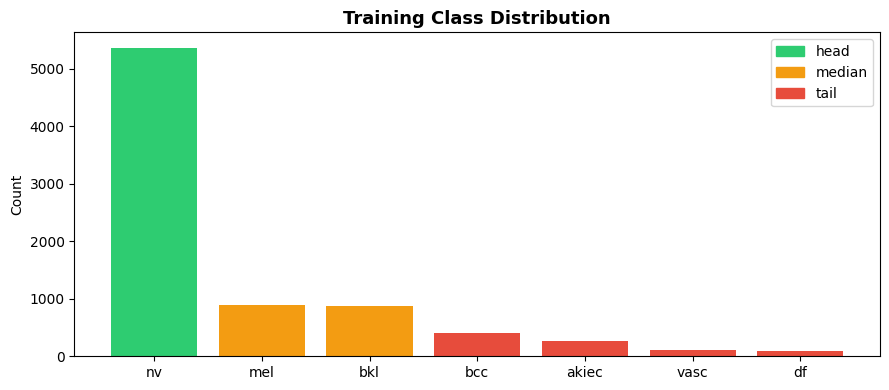

In [7]:
class_counts = Counter(train_df['dx'])
# Add this line at the top of Cell 1


def assign_group(cls):
    n = class_counts[cls]
    if n > HEAD_THRESH: return 'head'
    if n < TAIL_THRESH: return 'tail'
    return 'median'

CLASS_GROUPS   = {c: assign_group(c) for c in CLASS_NAMES}
TAIL_CLASSES   = [c for c, g in CLASS_GROUPS.items() if g == 'tail']
MEDIAN_CLASSES = [c for c, g in CLASS_GROUPS.items() if g == 'median']
HEAD_CLASSES   = [c for c, g in CLASS_GROUPS.items() if g == 'head']

print('Class groups:')
for c in CLASS_NAMES:
    print(f'  {c:8s}: {class_counts[c]:5d}  [{CLASS_GROUPS[c]}]')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(CLASS_NAMES, [class_counts[c] for c in CLASS_NAMES],
       color=[COLORS[CLASS_GROUPS[c]] for c in CLASS_NAMES])
ax.set_title('Training Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.legend(handles=[Patch(color=v, label=k) for k, v in COLORS.items()])
plt.tight_layout(); plt.show()

In [10]:
import os
import torch
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

CACHE_DIR = os.path.join(BASE_DIR, 'data', 'cache')
os.makedirs(CACHE_DIR, exist_ok=True)

cache_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

def build_cache(df, split_name):
    cache_path = os.path.join(CACHE_DIR, f'{split_name}.pt')
    if os.path.exists(cache_path):
        print(f'{split_name} cache already exists — skipping.')
        return
    imgs, labels = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'Caching {split_name}'):
        for ext in ('.jpg', '.jpeg', '.png'):
            p = os.path.join(IMAGE_DIR, row['image_id'] + ext)
            if os.path.exists(p):
                img = Image.open(p).convert('RGB')
                imgs.append(cache_transform(img))
                labels.append(int(row['label_idx']))
                break
    torch.save({'imgs': torch.stack(imgs), 'labels': torch.tensor(labels)}, cache_path)
    print(f'{split_name} cached: {len(imgs)} images → {cache_path}')

build_cache(train_df, 'train')
build_cache(val_df,   'val')
build_cache(test_df,  'test')
print('All caches built.')

Caching train: 100%|██████████| 8012/8012 [00:59<00:00, 135.10it/s]


train cached: 8012 images → D:\class imbalance\date-16\data\cache\train.pt


Caching val: 100%|██████████| 1001/1001 [00:07<00:00, 142.50it/s]


val cached: 1001 images → D:\class imbalance\date-16\data\cache\val.pt


Caching test: 100%|██████████| 1002/1002 [00:07<00:00, 129.38it/s]


test cached: 1002 images → D:\class imbalance\date-16\data\cache\test.pt
All caches built.


## 3. Dataset & Transforms

In [11]:
# ── Transforms (keep exactly as before) ───────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── Cache-based Dataset (reads pre-decoded tensors instead of raw JPEGs) ───────
class CachedHAMDataset(Dataset):
    def __init__(self, split_name, transform=None):
        cache_path = os.path.join(BASE_DIR, 'data', 'cache', f'{split_name}.pt')
        data       = torch.load(cache_path, map_location='cpu')
        self.imgs      = data['imgs']
        self.labels    = data['labels']
        self.transform = transform

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        img   = self.imgs[idx]
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(transforms.ToPILImage()(img))
        return img, label

train_ds = CachedHAMDataset('train', transform=train_transform)
val_ds   = CachedHAMDataset('val',   transform=eval_transform)
test_ds  = CachedHAMDataset('test',  transform=eval_transform)
print(f'Datasets: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}')

Datasets: train=8012, val=1001, test=1002


## 4. Three Samplers

In [12]:
def instance_sampler(df):
    return WeightedRandomSampler(torch.ones(len(df)), len(df), replacement=True)

def median_sampler(df):
    counts   = df['dx'].value_counts().to_dict()
    median_n = sorted(counts.values())[len(counts)//2]
    w = torch.tensor(np.clip(median_n / df['dx'].map(counts).values, 1.0, 5.0), dtype=torch.float)
    return WeightedRandomSampler(w, len(df), replacement=True)

def reverse_sampler(df):
    counts = df['dx'].value_counts().to_dict()
    freq   = df['dx'].map(counts).values
    w      = 1.0 / freq; w = w / w.sum() * len(w)
    return WeightedRandomSampler(torch.tensor(w, dtype=torch.float), len(df), replacement=True)
def make_loader(ds, sampler=None, shuffle=False):
    return DataLoader(
        ds,
        batch_size  = BATCH_SIZE,
        sampler     = sampler,
        shuffle     = shuffle if sampler is None else False,
        num_workers = NUM_WORKERS,
        pin_memory  = True,
    )

loader_instance = make_loader(train_ds, sampler=instance_sampler(train_df))
loader_median   = make_loader(train_ds, sampler=median_sampler(train_df))
loader_reverse  = make_loader(train_ds, sampler=reverse_sampler(train_df))
val_loader      = make_loader(val_ds,   shuffle=False)
test_loader     = make_loader(test_ds,  shuffle=False)
print('Loaders ready.')


Loaders ready.


## 5. Encoder (ResNet-50)

In [13]:
class Encoder(nn.Module):
    def __init__(self, out_dim=ENCODER_DIM):
        super().__init__()
        bb      = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_f    = bb.fc.in_features
        bb.fc   = nn.Identity()
        self.backbone = bb
        self.proj = nn.Sequential(
            nn.Linear(in_f, 1024), nn.BatchNorm1d(1024), nn.ReLU(inplace=True),
            nn.Linear(1024, out_dim))

    def forward(self, x):
        return self.proj(self.backbone(x))

enc = Encoder().to(DEVICE)
with torch.no_grad():
    out = enc(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print(f'Encoder output: {out.shape}')  # (2, 512)

Encoder output: torch.Size([2, 512])


## 6. CVAE

In [14]:
class CVAE(nn.Module):
    def __init__(self, feat_dim=ENCODER_DIM, lat_dim=LATENT_DIM, nc=NUM_CLASSES):
        super().__init__()
        self.lat_dim = lat_dim; self.nc = nc
        self.enc1    = nn.Linear(feat_dim + nc, 256)
        self.mu      = nn.Linear(256, lat_dim)
        self.logv    = nn.Linear(256, lat_dim)
        self.dec1    = nn.Linear(lat_dim + nc, 256)
        self.dec_out = nn.Linear(256, feat_dim)

    def encode(self, f, y):
        h = F.relu(self.enc1(torch.cat([f, y], -1)))
        return self.mu(h), self.logv(h)

    def decode(self, z, y):
        return self.dec_out(F.relu(self.dec1(torch.cat([z, y], -1))))

    def forward(self, f, labels):
        y = F.one_hot(labels, self.nc).float()
        mu, lv = self.encode(f, y)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.decode(z, y), mu, lv, z

def cvae_loss(recon, orig, mu, lv, beta=1.0):
    r = F.mse_loss(recon, orig)
    k = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
    return r + beta * k

print('CVAE ready.')

CVAE ready.


## 7. Supervised Contrastive Loss

In [15]:
class SupConLoss(nn.Module):
    def __init__(self, temp=TEMPERATURE):
        super().__init__(); self.temp = temp

    def forward(self, features, labels):
        B = features.shape[0]
        f = F.normalize(features.view(2*B, -1), dim=1)
        labels = labels.repeat(2)
        mask = torch.eq(labels.unsqueeze(0), labels.unsqueeze(1)).float().to(f.device)
        eye  = torch.eye(2*B, device=f.device)
        mask = mask * (1 - eye)
        logits = torch.mm(f, f.T) / self.temp
        exp_l  = torch.exp(logits) * (1 - eye)
        log_p  = logits - torch.log(exp_l.sum(1, keepdim=True) + 1e-9)
        return -(mask * log_p).sum(1).div(mask.sum(1) + 1e-9).mean()

print('SupConLoss ready.')

SupConLoss ready.


## 8. HybridMix

In [16]:
def cmeo_cutmix(a, b, la, lb, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    _, _, H, W = a.shape
    cr = np.sqrt(1 - lam)
    cw, ch = int(W*cr), int(H*cr)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1,x2 = np.clip(cx-cw//2,0,W), np.clip(cx+cw//2,0,W)
    y1,y2 = np.clip(cy-ch//2,0,H), np.clip(cy+ch//2,0,H)
    m = a.clone(); m[:,:,y1:y2,x1:x2] = b[:,:,y1:y2,x1:x2]
    return m, la, lb, 1-(x2-x1)*(y2-y1)/(H*W)

def do_mixup(a, b, la, lb, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    return lam*a + (1-lam)*b, la, lb, lam

def hybrid_mix(imgs, labels):
    B = imgs.size(0)
    perm = torch.randperm(B)
    ib, lb = imgs[perm], labels[perm]
    is_tail = torch.tensor([IDX2LABEL[l.item()] in TAIL_CLASSES for l in labels])
    mixed = torch.zeros_like(imgs); lam_v = torch.ones(B)
    if is_tail.sum() > 0:
        m,_,_,l = do_mixup(imgs[is_tail], ib[is_tail], labels[is_tail], lb[is_tail])
        mixed[is_tail] = m; lam_v[is_tail] = l
    ih = ~is_tail
    if ih.sum() > 0:
        m,_,_,l = cmeo_cutmix(imgs[ih], ib[ih], labels[ih], lb[ih])
        mixed[ih] = m; lam_v[ih] = l
    return mixed, labels, lb, lam_v

print('HybridMix ready.')

HybridMix ready.


## 9. STTP-Net (Dual-Head)

In [17]:
class Head(nn.Module):
    def __init__(self, in_d, nc, drop=0.4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Dropout(drop), nn.Linear(in_d,256), nn.ReLU(inplace=True),
            nn.Dropout(drop*0.5), nn.Linear(256, nc))
    def forward(self, x): return self.fc(x)

class STTPNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder(ENCODER_DIM)
        self.cvae    = CVAE(ENCODER_DIM, LATENT_DIM, NUM_CLASSES)
        self.head1   = Head(ENCODER_DIM, NUM_CLASSES)
        self.head2   = Head(ENCODER_DIM, NUM_CLASSES)
        self.sc_proj = nn.Sequential(
            nn.Linear(ENCODER_DIM,128), nn.ReLU(inplace=True), nn.Linear(128,128))

    def forward(self, x, labels=None, use_cvae=True):
        f  = self.encoder(x)
        cv = self.cvae(f, labels) if (use_cvae and labels is not None) else None
        return self.head1(f), self.head2(f), self.sc_proj(f), f, cv

    def fused_logits(self, x):
        f  = self.encoder(x)
        l1 = self.head1(f); l2 = self.head2(f)
        return (l1/self.head1.fc[-1].weight.norm() +
                l2/self.head2.fc[-1].weight.norm()) * 0.5

model = STTPNet().to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Parameters: 26,846,798


## 10. EBS Loss

In [18]:
class EBSLoss(nn.Module):
    def __init__(self, counts):
        super().__init__()
        n = torch.tensor([float(counts.get(c,1)) for c in CLASS_NAMES])
        self.register_buffer('log_n', torch.log(n))
    def forward(self, logits, labels):
        return F.cross_entropy(logits + self.log_n.to(logits.device), labels)

def mixed_ce(logits, la, lb, lam, loss_fn):
    if isinstance(lam, torch.Tensor):
        lam = lam.to(logits.device)
        return (lam * F.cross_entropy(logits, la.to(logits.device), reduction='none')
              + (1-lam) * F.cross_entropy(logits, lb.to(logits.device), reduction='none')).mean()
    return lam*loss_fn(logits,la) + (1-lam)*loss_fn(logits,lb)

ebs     = EBSLoss(class_counts).to(DEVICE)
sup_con = SupConLoss().to(DEVICE)
print('Loss functions ready.')

Loss functions ready.


## 11. Train & Evaluate

In [19]:
def train_epoch(model, opt, use_hm=True):
    model.train()
    total, n = 0.0, 0
    it_med = iter(loader_median)
    it_rev = iter(loader_reverse)

    for imgs_i, lbl_i in tqdm(loader_instance, desc='  train', leave=False):
        try:    imgs_m, lbl_m = next(it_med)
        except: it_med = iter(loader_median);  imgs_m, lbl_m = next(it_med)
        try:    imgs_r, lbl_r = next(it_rev)
        except: it_rev = iter(loader_reverse); imgs_r, lbl_r = next(it_rev)

        imgs_i,lbl_i = imgs_i.to(DEVICE), lbl_i.to(DEVICE)
        imgs_m,lbl_m = imgs_m.to(DEVICE), lbl_m.to(DEVICE)
        imgs_r,lbl_r = imgs_r.to(DEVICE), lbl_r.to(DEVICE)
        opt.zero_grad()

        # Head-1: instance + median
        imgs_hm = torch.cat([imgs_i, imgs_m])
        lbl_hm  = torch.cat([lbl_i,  lbl_m])
        if use_hm:
            imgs_hm, la, lb, lam = hybrid_mix(imgs_hm, lbl_hm)
            imgs_hm=imgs_hm.to(DEVICE); la=la.to(DEVICE); lb=lb.to(DEVICE)

        l1, _, _, f_hm, cv = model(imgs_hm, lbl_hm, use_cvae=True)
        loss_h1 = mixed_ce(l1, la, lb, lam, ebs) if use_hm else ebs(l1, lbl_hm)

        loss_cv = torch.tensor(0., device=DEVICE)
        if cv is not None:
            recon, mu, lv, _ = cv
            loss_cv = cvae_loss(recon, f_hm.detach(), mu, lv)

        # Head-2: reverse / tail-heavy
        if use_hm:
            imgs_r2, la_r, lb_r, lam_r = hybrid_mix(imgs_r, lbl_r)
            imgs_r2=imgs_r2.to(DEVICE); la_r=la_r.to(DEVICE); lb_r=lb_r.to(DEVICE)
        else:
            imgs_r2 = imgs_r

        _, l2, _, _, _ = model(imgs_r2, lbl_r, use_cvae=False)
        loss_h2 = mixed_ce(l2, la_r, lb_r, lam_r, ebs) if use_hm else ebs(l2, lbl_r)

        # SupCon on clean batch
        _, _, proj_sc, _, _ = model(imgs_i, lbl_i, use_cvae=False)
        loss_sc = sup_con(proj_sc.unsqueeze(1).repeat(1,2,1), lbl_i)

        loss = loss_h1 + loss_h2 + 0.3*loss_sc + 0.2*loss_cv
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()
        total += loss.item(); n += 1

    return total / max(n, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labels, probs = [], [], []
    for imgs, lbl in loader:
        p = F.softmax(model.fused_logits(imgs.to(DEVICE)), -1).cpu()
        preds.append(p.argmax(-1)); labels.append(lbl); probs.append(p)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    probs  = torch.cat(probs).numpy()
    return ((preds==labels).mean(),
            balanced_accuracy_score(labels, preds),
            preds, labels, probs)


@torch.no_grad()
def evaluate_tta(model, loader, n_tta=5):
    model.eval()
    tta_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    preds, labels, probs = [], [], []
    for imgs, lbl in tqdm(loader, desc='  TTA', leave=False):
        B = imgs.size(0)
        bp = torch.zeros(B, NUM_CLASSES)
        bp += F.softmax(model.fused_logits(imgs.to(DEVICE)), -1).cpu()
        for _ in range(n_tta - 1):
            aug = []
            for t in imgs:
                np_img = t.permute(1,2,0).numpy()
                np_img = (np_img*np.array([0.229,0.224,0.225])+np.array([0.485,0.456,0.406]))
                np_img = np.clip(np_img*255,0,255).astype(np.uint8)
                aug.append(tta_tf(Image.fromarray(np_img)))
            bp += F.softmax(model.fused_logits(torch.stack(aug).to(DEVICE)), -1).cpu()
        bp /= n_tta
        preds.append(bp.argmax(-1)); labels.append(lbl); probs.append(bp)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    probs  = torch.cat(probs).numpy()
    return ((preds==labels).mean(),
            balanced_accuracy_score(labels, preds),
            preds, labels, probs)


print('All functions ready.')

All functions ready.


## 12. Two-Phase Training

In [20]:
# ── Experiment folder ─────────────────────────────────────────────────────────
EXP_NAME = 'exp06_resnet50_baseline_v2'
EXP_DIR  = os.path.join(BASE_DIR, 'experiments', EXP_NAME)
os.makedirs(EXP_DIR, exist_ok=True)

config = {
    'exp_name':      EXP_NAME,
    'epochs_phase1': EPOCHS_PHASE1,
    'epochs_phase2': EPOCHS_PHASE2,
    'batch_size':    BATCH_SIZE,
    'lr':            LR,
    'encoder':       'ResNet-50 (ImageNet pretrained)',
    'augmentation':  'torchvision basic — HFlip, VFlip, ColorJitter(0.2), Rotation(20)',
    'loss':          'EBS only',
    'notes':         'Exact replication of exp01 baseline that gave 0.904 acc / 0.869 bal',
}
with open(os.path.join(EXP_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print(f'Experiment : {EXP_NAME}')
print(f'Saving to  : {EXP_DIR}')

# ── Optimizer & scheduler ─────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_PHASE1+EPOCHS_PHASE2, eta_min=1e-6)

history   = {'epoch':[], 'loss':[], 'val_acc':[], 'val_bal':[], 'phase':[]}
best_bal  = 0.0
best_ckpt = os.path.join(EXP_DIR, 'best_model.pt')

# ── Training loop ─────────────────────────────────────────────────────────────
torch.cuda.empty_cache()
for epoch in range(1, EPOCHS_PHASE1+EPOCHS_PHASE2+1):
    phase  = 'HybridMix' if epoch <= EPOCHS_PHASE1 else 'Boundary Refinement'
    use_hm = epoch <= EPOCHS_PHASE1
    print(f'\nEpoch {epoch}/{EPOCHS_PHASE1+EPOCHS_PHASE2}  [{phase}]')

    loss = train_epoch(model, optimizer, use_hm)
    acc, bal, _, _, _ = evaluate(model, val_loader)
    scheduler.step()

    history['epoch'].append(epoch); history['loss'].append(loss)
    history['val_acc'].append(acc); history['val_bal'].append(bal)
    history['phase'].append(phase)
    print(f'  Loss={loss:.4f}  Val Acc={acc:.4f}  Val Balanced={bal:.4f}')

    if bal > best_bal:
        best_bal = bal
        torch.save(model.state_dict(), best_ckpt)
        print(f'  [best saved  bal={bal:.4f}]')

print(f'\nDone. Best val balanced acc: {best_bal:.4f}')

Experiment : exp06_resnet50_baseline_v2
Saving to  : D:\class imbalance\date-16\experiments\exp06_resnet50_baseline_v2

Epoch 1/40  [HybridMix]


  Loss=3.4130  Val Acc=0.7512  Val Balanced=0.7436
  [best saved  bal=0.7436]

Epoch 2/40  [HybridMix]


  Loss=2.9965  Val Acc=0.8212  Val Balanced=0.8203
  [best saved  bal=0.8203]

Epoch 3/40  [HybridMix]


  Loss=2.8758  Val Acc=0.8152  Val Balanced=0.8020

Epoch 4/40  [HybridMix]


  Loss=2.7763  Val Acc=0.8282  Val Balanced=0.8252
  [best saved  bal=0.8252]

Epoch 5/40  [HybridMix]


...

  Loss=1.0885  Val Acc=0.9081  Val Balanced=0.8450

Epoch 37/40  [Boundary Refinement]


  Loss=1.0852  Val Acc=0.9081  Val Balanced=0.8440

Epoch 38/40  [Boundary Refinement]


  Loss=1.0858  Val Acc=0.9061  Val Balanced=0.8413

Epoch 39/40  [Boundary Refinement]


  Loss=1.0861  Val Acc=0.9101  Val Balanced=0.8422

Epoch 40/40  [Boundary Refinement]


  Loss=1.0837  Val Acc=0.9101  Val Balanced=0.8450

Done. Best val balanced acc: 0.8844


## 13. Training Curves

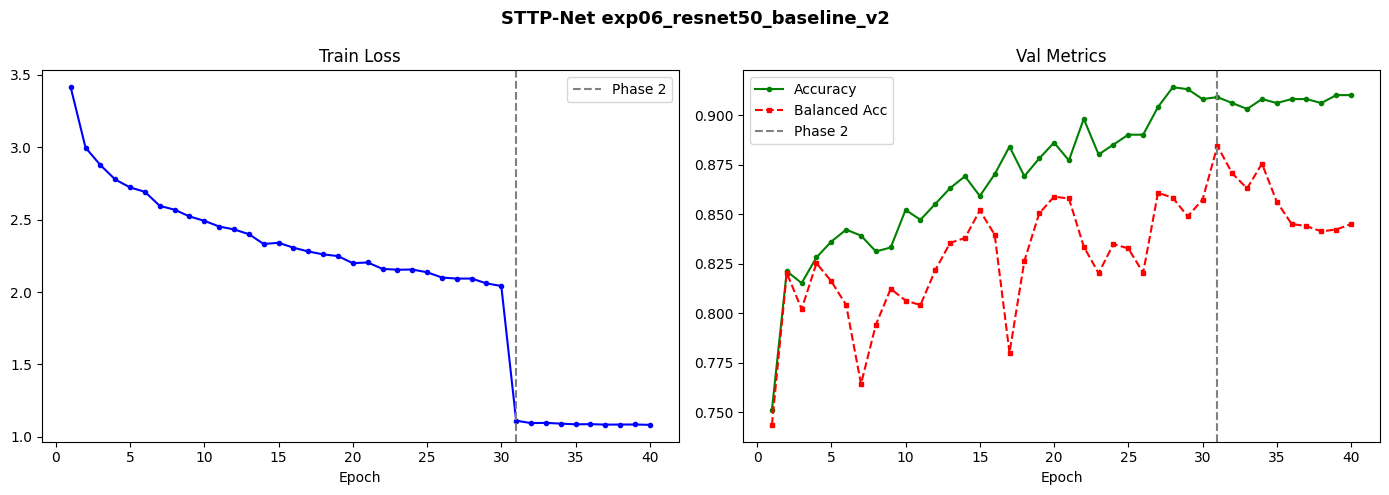

In [21]:
p2 = next((e for e,p in zip(history['epoch'],history['phase']) if p=='Boundary Refinement'), None)
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(history['epoch'], history['loss'], 'b-o', ms=3)
if p2: axes[0].axvline(p2, color='gray', ls='--', label='Phase 2')
axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['epoch'], history['val_acc'], 'g-o',  ms=3, label='Accuracy')
axes[1].plot(history['epoch'], history['val_bal'], 'r--s', ms=3, label='Balanced Acc')
if p2: axes[1].axvline(p2, color='gray', ls='--', label='Phase 2')
axes[1].set_title('Val Metrics'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle(f'STTP-Net {EXP_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 14. Test Evaluation

In [22]:
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
test_acc, test_bal, test_preds, test_labels, test_probs = evaluate_tta(model, test_loader, n_tta=5)
print(f'Test Accuracy          : {test_acc:.4f}')
print(f'Test Balanced Accuracy : {test_bal:.4f}\n')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))

Test Accuracy          : 0.9102
Test Balanced Accuracy : 0.8764

              precision    recall  f1-score   support

          nv     0.9581    0.9553    0.9567       671
         mel     0.7593    0.7321    0.7455       112
         bkl     0.8304    0.8455    0.8378       110
         bcc     0.8889    0.9231    0.9057        52
       akiec     0.7273    0.7500    0.7385        32
        vasc     0.8667    0.9286    0.8966        14
          df     1.0000    1.0000    1.0000        11

    accuracy                         0.9102      1002
   macro avg     0.8615    0.8764    0.8687      1002
weighted avg     0.9101    0.9102    0.9101      1002



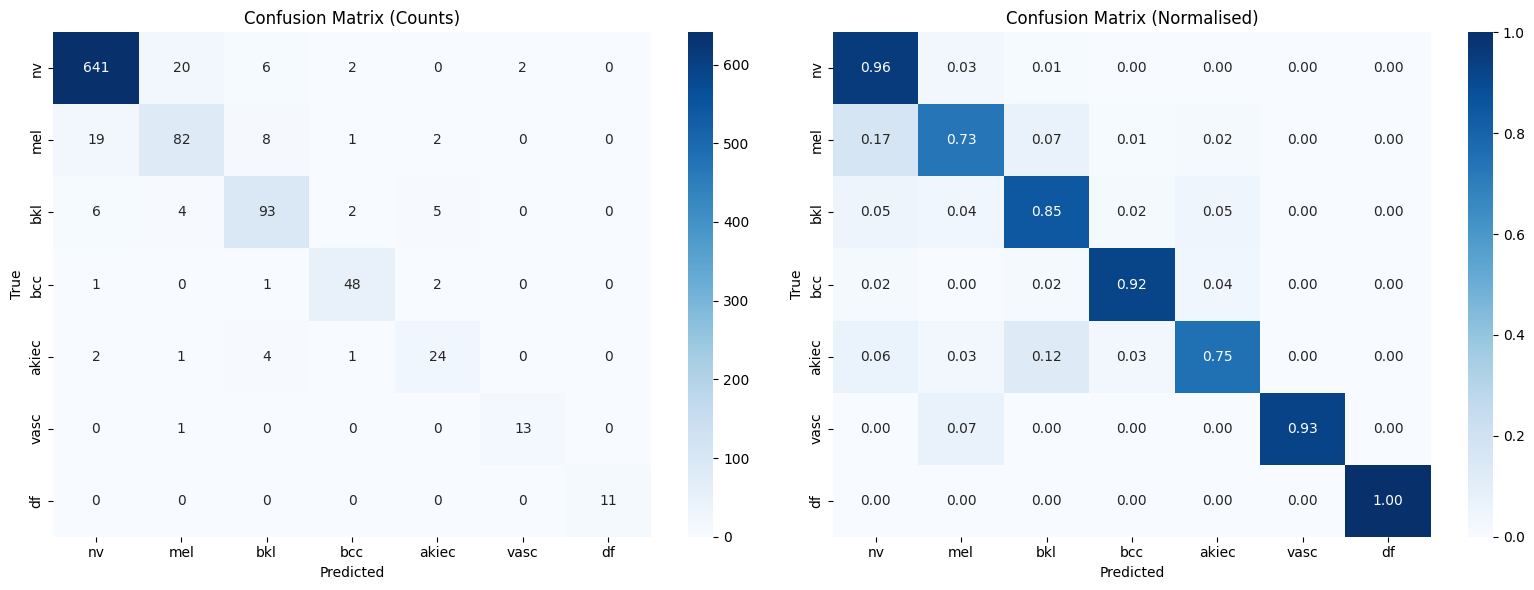

In [23]:
cm = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1,2,figsize=(16,6))
for ax, data, title, fmt in zip(axes,
    [cm, cm.astype(float)/cm.sum(1,keepdims=True)],
    ['Counts','Normalised'], ['d','.2f']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix ({title})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

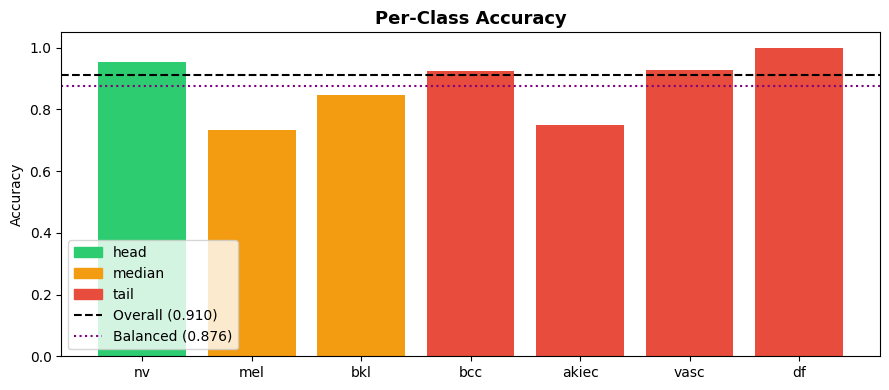

In [24]:
per = {IDX2LABEL[i]: (test_preds[test_labels==i]==i).mean()
       for i in range(NUM_CLASSES) if (test_labels==i).sum()>0}
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(per.keys(), per.values(),
       color=[COLORS[CLASS_GROUPS[c]] for c in per])
ax.axhline(test_acc, color='black',  ls='--', label=f'Overall ({test_acc:.3f})')
ax.axhline(test_bal, color='purple', ls=':',  label=f'Balanced ({test_bal:.3f})')
ax.set_ylim(0,1.05); ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy', fontsize=13, fontweight='bold')
ax.legend(handles=[
    Patch(color=v,label=k) for k,v in COLORS.items()
]+[
    plt.Line2D([0],[0],color='black', ls='--',label=f'Overall ({test_acc:.3f})'),
    plt.Line2D([0],[0],color='purple',ls=':' ,label=f'Balanced ({test_bal:.3f})')
])
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'per_class_acc.png'), dpi=150)
plt.show()

## 15. Macro-AUC

In [25]:
try:
    auc = roc_auc_score(label_binarize(test_labels, classes=list(range(NUM_CLASSES))),
                        test_probs, multi_class='ovr', average='macro')
    print(f'Macro AUC: {auc:.4f}')
except Exception as e:
    print(f'AUC skipped: {e}')

Macro AUC: 0.9819


## 16. t-SNE Latent Space

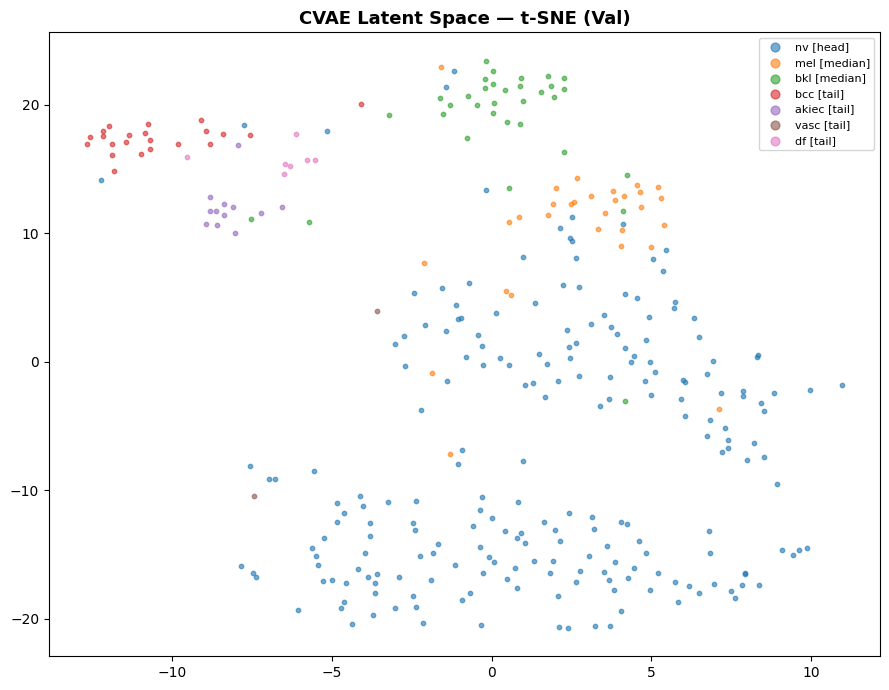

In [26]:
from sklearn.manifold import TSNE

@torch.no_grad()
def get_latents(loader, max_batches=20):
    model.eval()
    fs, ls = [], []
    for i,(imgs,lbl) in enumerate(loader):
        if i >= max_batches: break
        f = model.encoder(imgs.to(DEVICE))
        y = F.one_hot(lbl.to(DEVICE), NUM_CLASSES).float()
        mu,_ = model.cvae.encode(f, y)
        fs.append(mu.cpu().numpy()); ls.append(lbl.numpy())
    return np.concatenate(fs), np.concatenate(ls)

feats, lbls = get_latents(val_loader)
emb = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000).fit_transform(feats)

fig, ax = plt.subplots(figsize=(9,7))
cmap = plt.get_cmap('tab10')
for i, cls in IDX2LABEL.items():
    m = lbls==i
    ax.scatter(emb[m,0], emb[m,1], label=f'{cls} [{CLASS_GROUPS[cls]}]',
               alpha=0.6, s=10, color=cmap(i))
ax.set_title('CVAE Latent Space — t-SNE (Val)', fontsize=13, fontweight='bold')
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'tsne_latent.png'), dpi=150)
plt.show()

## 17. Save Results

In [27]:
out = {
    'exp_name':               EXP_NAME,
    'test_accuracy':          round(float(test_acc), 4),
    'test_balanced_accuracy': round(float(test_bal), 4),
    'best_val_balanced_acc':  round(best_bal, 4),
    'class_groups':           CLASS_GROUPS,
    'architecture':           'ResNet-50 + CVAE + SupCon + HybridMix + DualHead + EBS',
    'phases': {
        'phase1': f'{EPOCHS_PHASE1} epochs HybridMix',
        'phase2': f'{EPOCHS_PHASE2} epochs Boundary Refinement'
    },
}
path = os.path.join(EXP_DIR, 'results_summary.json')
with open(path, 'w') as f:
    json.dump(out, f, indent=2)
print('Saved:', path)
print(json.dumps(out, indent=2))

Saved: D:\class imbalance\date-16\experiments\exp06_resnet50_baseline_v2\results_summary.json
{
  "exp_name": "exp06_resnet50_baseline_v2",
  "test_accuracy": 0.9102,
  "test_balanced_accuracy": 0.8764,
  "best_val_balanced_acc": 0.8844,
  "class_groups": {
    "nv": "head",
    "mel": "median",
    "bkl": "median",
    "bcc": "tail",
    "akiec": "tail",
    "vasc": "tail",
    "df": "tail"
  },
  "architecture": "ResNet-50 + CVAE + SupCon + HybridMix + DualHead + EBS",
  "phases": {
    "phase1": "30 epochs HybridMix",
    "phase2": "10 epochs Boundary Refinement"
  }
}
